# TSLA vs MSFT — 72-run sweep analysis

Every number and figure in `analyses/tsla_msft_200days_report.html`, recomputed from
`results.csv` and `additions.csv` (both written by `pull_and_analyze.py` straight from
MLflow).

The design is two balanced 36-run halves. They differ in exactly two ways:

| | TSLA half | MSFT half |
|---|---|---|
| label | TSLA next-day direction | MSFT next-day direction |
| articles | **mixed** — TSLA + MSFT + NVDA | **MSFT only** (`--filter-ticker`) |
| chunks | 01–13, 2026-08-08/09 | 14–26, 2026-08-12/14 |

Everything else — window, orthogonal array, gate, feature construction — is identical.
So the comparison answers one question: **does focusing the corpus on the labelled
company change anything?**

Figures here use default matplotlib. The report's styled versions come from
`make_figures.py`, from this same data.

In [1]:
import warnings
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

TICKERS = ["TSLA", "MSFT"]
FACTORS = ["lookback_days", "steps", "chain_hops", "evolution_prompt"]

runs = pd.read_csv("results.csv")
adds = pd.read_csv("additions.csv")

print(f"runs      {len(runs)}  ({runs.ticker.value_counts().to_dict()})")
print(f"additions {len(adds)}  ({adds.ticker.value_counts().to_dict()})")

runs      72  ({'TSLA': 36, 'MSFT': 36})
additions 720  ({'TSLA': 360, 'MSFT': 360})


This notebook reproduces every number the report states. Sections A–F and G's verdict are
descriptive; section G collects the formal tests behind the report's summary table.

A fuller treatment of the testing — multiplicity, per-addition binomials, and why ANOVA
rather than the sampling SE of a single AUC — is in `stats_tests_note.ipynb` alongside.

## A · What was run

Four hyperparameters vary at once. The full grid is 4 × 3 × 3 × 3 = 108; each half runs
36 of them, chosen so every *pair* of levels appears equally often. That is what makes
a level-vs-level comparison fair without any regression adjustment.

In [2]:
# Held fixed within each half: every one of these should have a single distinct value.
fixed = runs.groupby("ticker")[["baseline_auc"]].size().rename("n_runs").to_frame()
fixed["distinct lookback"] = runs.groupby("ticker").lookback_days.nunique()
fixed["distinct steps"] = runs.groupby("ticker").steps.nunique()
fixed["distinct hops"] = runs.groupby("ticker").chain_hops.nunique()
fixed["distinct prompts"] = runs.groupby("ticker").evolution_prompt.nunique()
fixed

,n_runs,distinct lookback,distinct steps,distinct hops,distinct prompts
ticker,,,,,
MSFT,36,4,3,3,3
TSLA,36,4,3,3,3


In [3]:
# Pairwise balance: for every PAIR of factors, does every level combination appear,
# and equally often? This is the strength-2 property the design claims.
def balance(df):
    out = []
    for i, a in enumerate(FACTORS):
        for b in FACTORS[i + 1:]:
            counts = df.groupby([a, b]).size()
            expected = len(df[a].unique()) * len(df[b].unique())
            out.append({
                "pair": f"{a} x {b}",
                "cells seen": len(counts),
                "cells possible": expected,
                "missing": expected - len(counts),
                "lambda": sorted(counts.unique().tolist()),
            })
    return pd.DataFrame(out)

for t in TICKERS:
    print(f"--- {t} ---")
    print(balance(runs[runs.ticker == t]).to_string(index=False))
    print()

--- TSLA ---
                            pair  cells seen  cells possible  missing lambda
           lookback_days x steps          12              12        0    [3]
      lookback_days x chain_hops          12              12        0    [3]
lookback_days x evolution_prompt          12              12        0    [3]
              steps x chain_hops           9               9        0    [4]
        steps x evolution_prompt           9               9        0    [4]
   chain_hops x evolution_prompt           9               9        0    [4]

--- MSFT ---
                            pair  cells seen  cells possible  missing lambda
           lookback_days x steps          12              12        0    [3]
      lookback_days x chain_hops          12              12        0    [3]
lookback_days x evolution_prompt          12              12        0    [3]
              steps x chain_hops           9               9        0    [4]
        steps x evolution_prompt           9     

No missing cells in either half, and each combination appears 3 or 4 times depending on
how many levels the two factors carry. Both halves are genuine `OA(36, 4¹3³, 2)`.

In [4]:
# Article composition. Recomputed through the real code path rather than quoted, because
# the per-day cap is sensitive to how ties are broken (see the caveat cell below).
from datetime import date, timedelta

CSV = "../../data/fnspid_sample_nasdaq_long_text.csv"
SPLIT = pd.Timestamp("2022-09-20 23:59:59")   # last training price day

raw = pd.read_csv(CSV)
raw["timestamp"] = pd.to_datetime(raw["timestamp"])
start, end = date(2022, 5, 2), date(2022, 5, 2) + timedelta(days=200)
in_window = (raw.timestamp.dt.date >= start) & (raw.timestamp.dt.date < end)
window_fileorder = raw[in_window].copy()          # untouched row order, for the tie demo
# The production path sorts before slicing (core/data.py), so mirror that exactly.
raw = raw.sort_values("timestamp").reset_index(drop=True)
window = raw[(raw.timestamp.dt.date >= start) & (raw.timestamp.dt.date < end)].copy()

def compose(df, ticker=None):
    d = df[df.ticker == ticker].copy() if ticker else df.copy()
    d["day"] = d.timestamp.dt.strftime("%Y-%m-%d")
    sel = d.groupby("day").head(4).reset_index(drop=True)
    rows = []
    for name, part in [("training", sel[sel.timestamp <= SPLIT]),
                       ("validation", sel[sel.timestamp > SPLIT]),
                       ("total", sel)]:
        r = {"split": name, "articles": len(part), "days": part.day.nunique(),
             "per day": round(len(part) / part.day.nunique(), 2)}
        for tk in ["TSLA", "MSFT", "NVDA"]:
            n = int((part.ticker == tk).sum())
            r[tk] = f"{n} ({100 * n / len(part):.0f}%)" if n else "—"
        rows.append(r)
    return pd.DataFrame(rows)

print("TSLA half — mixed articles"); display(compose(window))
print("MSFT half — MSFT-only articles"); display(compose(window, "MSFT"))

TSLA half — mixed articles


,split,articles,days,per day,TSLA,MSFT,NVDA
0,training,562,142,3.96,232 (41%),205 (36%),125 (22%)
1,validation,232,58,4.00,78 (34%),104 (45%),50 (22%)
2,total,794,200,3.97,310 (39%),309 (39%),175 (22%)


MSFT half — MSFT-only articles


,split,articles,days,per day,TSLA,MSFT,NVDA
0,training,499,139,3.59,—,499 (100%),—
1,validation,213,57,3.74,—,213 (100%),—
2,total,712,196,3.63,—,712 (100%),—


**A caveat that belongs right here.** Every article on a given day carries the *same*
timestamp, so `sort_values` leaves them tied and `groupby("day").head(4)` takes whichever
four the sort happened to put first. The selection is deterministic for a given pandas
build (verified identical under 1.3.5 and the locked 2.3.3) but it is **not** a random
sample and **not** the most recent four — it is an arbitrary-but-stable slice.

For the MSFT half this cannot affect composition, since filtering happens before the cap
and everything kept is MSFT either way. For the TSLA half it fully determines the mix.

In [5]:
# The tie problem, quantified.
print(f"articles in window          {len(window):,}")
print(f"distinct timestamps         {window.timestamp.nunique()}")
print(f"articles per distinct stamp {len(window) / window.timestamp.nunique():.1f}")
print(f"sample timestamps           {sorted(window.timestamp.unique())[:3]}")
print()
print("So the 4/day cap chooses 4 of ~30 mutually tied rows, and *which* four is decided")
print("by row order alone. Same data, same cap, two orderings:\n")

def mix(df):
    d = df.assign(day=df.timestamp.dt.strftime("%Y-%m-%d"))
    return d.groupby("day").head(4).ticker.value_counts().to_dict()

print("  file order (a stable sort would keep this):", mix(window_fileorder))
print("  as executed (pandas default quicksort)    :", mix(window))
print()
print("The first is what core/data.py's docstring records; the second is what actually")
print("ran. Neither is more correct — that is the defect.")

articles in window          5,987
distinct timestamps         200
articles per distinct stamp 29.9
sample timestamps           [Timestamp('2022-05-02 00:00:00'), Timestamp('2022-05-03 00:00:00'), Timestamp('2022-05-04 00:00:00')]

So the 4/day cap chooses 4 of ~30 mutually tied rows, and *which* four is decided
by row order alone. Same data, same cap, two orderings:

  file order (a stable sort would keep this): {'MSFT': 712, 'NVDA': 51, 'TSLA': 31}
  as executed (pandas default quicksort)    : {'TSLA': 310, 'MSFT': 309, 'NVDA': 175}

The first is what core/data.py's docstring records; the second is what actually
ran. Neither is more correct — that is the defect.


## B · Results, side by side

Each run ends at its **final accepted ontology**. `baseline_auc` is that same run's
article-text arm on the same validation days. The two arms share no features —
`build_day_feature_vector` skips text entirely — so `delta` contrasts two disjoint
representations rather than ablating the ontology.

In [6]:
summary = runs.groupby("ticker")[["final_auc", "baseline_auc", "delta", "brier_score"]].agg(
    ["mean", "std", "median", "min", "max"]
).T.unstack(0)
summary.columns = summary.columns.droplevel(0)
summary.round(4)

,final_auc,baseline_auc,delta,brier_score,final_auc,baseline_auc,delta,brier_score
mean,0.6092,0.5648,0.0444,0.2983,0.6168,0.5629,0.0538,0.2931
std,0.0640,0.0269,0.0701,0.0332,0.0649,0.0531,0.0844,0.0407
median,0.6182,0.5648,0.0466,0.3014,0.6098,0.5400,0.0606,0.2903
min,0.4523,0.5273,-0.1500,0.2316,0.4691,0.5217,-0.1259,0.1991
max,0.7409,0.6023,0.2000,0.3656,0.7872,0.6499,0.2654,0.3885


In [7]:
side = pd.DataFrame(index=["mean final AUC", "mean text baseline", "mean delta",
                           "SD of delta", "beat baseline", "best run", "worst run"])
for t in TICKERS:
    s = runs[runs.ticker == t]
    side[t] = [
        f"{s.final_auc.mean():.4f}", f"{s.baseline_auc.mean():.4f}",
        f"{s.delta.mean():+.4f}", f"{s.delta.std():.4f}",
        f"{(s.delta > 0).sum()}/{len(s)}",
        f"{s.final_auc.max():.4f}", f"{s.final_auc.min():.4f}",
    ]
side["difference"] = ["", "", "", "", "", "", ""]
side.loc["mean final AUC", "difference"] = (
    f"{runs[runs.ticker=='MSFT'].final_auc.mean() - runs[runs.ticker=='TSLA'].final_auc.mean():+.4f}")
side.loc["mean delta", "difference"] = (
    f"{runs[runs.ticker=='MSFT'].delta.mean() - runs[runs.ticker=='TSLA'].delta.mean():+.4f}")
side

,TSLA,MSFT,difference
mean final AUC,0.6168,0.6092,-0.0076
mean text baseline,0.5629,0.5648,
mean delta,+0.0538,+0.0444,-0.0095
SD of delta,0.0844,0.0701,
beat baseline,28/36,28/36,
best run,0.7872,0.7409,
worst run,0.4691,0.4523,


In [8]:
# Top 5 per ticker, shown together.
cols = ["final_auc", "baseline_auc", "delta", "lookback_days", "steps",
        "chain_hops", "evolution_prompt", "path_mean_norm"]
for t in TICKERS:
    print(f"--- {t}: top 5 of 36 ---")
    print(runs[runs.ticker == t].nlargest(5, "final_auc")[cols].to_string(index=False))
    print()

--- TSLA: top 5 of 36 ---
 final_auc  baseline_auc    delta  lookback_days  steps  chain_hops evolution_prompt  path_mean_norm
  0.787185      0.521739 0.265446              3      3           3          default        0.792126
  0.743707      0.649886 0.093822             20      5           3     event_driven        0.150222
  0.729977      0.521739 0.208238             10      3           5     event_driven        0.000000
  0.723112      0.558352 0.164760              8      3           5     event_driven        0.000000
  0.700229      0.521739 0.178490             10      7           5          default        0.000000

--- MSFT: top 5 of 36 ---
 final_auc  baseline_auc    delta  lookback_days  steps  chain_hops evolution_prompt  path_mean_norm
  0.740909      0.602273 0.138636             10      5           3     event_driven        0.503306
  0.727273      0.527273 0.200000              3      3           3          default        0.451243
  0.688636      0.602273 0.086364     

In [9]:
# The text baseline depends only on lookback_days — the footnote under the top-5 tables.
# `nunique == 1` is the claim: every run at a given lookback shares one baseline exactly.
runs.groupby(["ticker", "lookback_days"]).baseline_auc.agg(
    n="size", distinct="nunique", value="mean"
).round(4)

n  distinct   value
ticker lookback_days                     
MSFT   3              9         1  0.5273
       8              9         1  0.5636
       10             9         1  0.6023
       20             9         1  0.5659
TSLA   3              9         1  0.5217
       8              9         1  0.5584
       10             9         1  0.5217
       20             9         1  0.6499

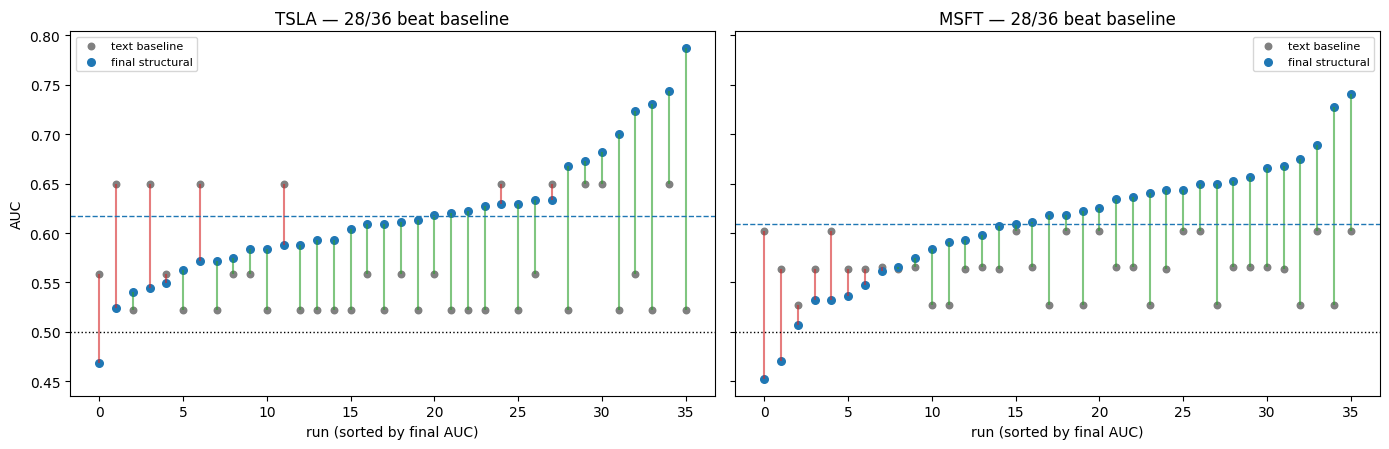

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
for ax, t in zip(axes, TICKERS):
    s = runs[runs.ticker == t].sort_values("final_auc").reset_index(drop=True)
    ax.vlines(s.index, s.baseline_auc, s.final_auc,
              color=np.where(s.delta > 0, "tab:green", "tab:red"), alpha=.6)
    ax.scatter(s.index, s.baseline_auc, s=22, color="gray", label="text baseline")
    ax.scatter(s.index, s.final_auc, s=30, label="final structural")
    ax.axhline(0.5, ls=":", color="k", lw=1)
    ax.axhline(s.final_auc.mean(), ls="--", lw=1)
    ax.set_title(f"{t} — {(s.delta > 0).sum()}/36 beat baseline")
    ax.set_xlabel("run (sorted by final AUC)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("AUC")
plt.tight_layout(); plt.show()

### Per-run lift

Each run pairs a graph AUC with a text AUC on the same validation days, so the lift is a
within-run contrast. Both halves land on exactly 28 of 36.

The shaded band is ±1 SD of that ticker's own 36 final AUCs — the ordinary scatter between
runs. It is the reference used throughout the report: a difference smaller than this band
is not distinguishable from the variation between two runs of the same configuration.

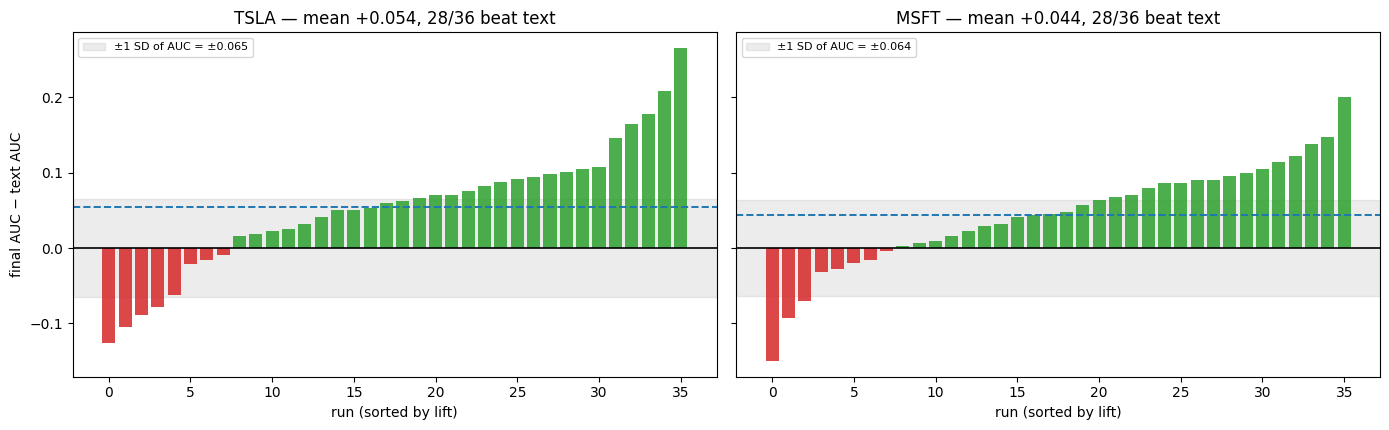

TSLA: mean lift +0.0538   between-run SD of AUC 0.0649   28/36 beat text
MSFT: mean lift +0.0444   between-run SD of AUC 0.0640   28/36 beat text


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
for ax, t in zip(axes, TICKERS):
    sub = runs[runs.ticker == t]
    sd = sub.final_auc.std()                      # between-run SD of AUC
    d = sub.delta.sort_values().reset_index(drop=True)
    ax.axhspan(-sd, sd, color="gray", alpha=.15, label=f"±1 SD of AUC = ±{sd:.3f}")
    ax.bar(d.index, d, color=np.where(d > 0, "tab:green", "tab:red"), alpha=.85)
    ax.axhline(0, color="k", lw=1.2)
    ax.axhline(d.mean(), ls="--", lw=1.4)
    ax.set_title(f"{t} — mean {d.mean():+.3f}, {int((d > 0).sum())}/36 beat text")
    ax.set_xlabel("run (sorted by lift)")
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("final AUC − text AUC")
plt.tight_layout(); plt.show()

for t in TICKERS:
    sub = runs[runs.ticker == t]
    print(f"{t}: mean lift {sub.delta.mean():+.4f}   between-run SD of AUC "
          f"{sub.final_auc.std():.4f}   {int((sub.delta > 0).sum())}/36 beat text")

## C · Do path-chain features help?

`path_mean_norm` is the mean Euclidean length of each day's 384-dimension path vector,
averaged over the run: 0 means the block was entirely zeros.

In [12]:
rows = []
for t in TICKERS:
    s = runs[runs.ticker == t]
    rho, p = stats.spearmanr(s.path_mean_norm, s.final_auc)
    slope = np.polyfit(s.path_mean_norm, s.final_auc, 1)[0]
    rows.append({"ticker": t, "spearman rho": round(rho, 4), "p": round(p, 3),
                 "OLS slope": round(slope, 4),
                 "runs with empty path block": int((s.path_mean_norm == 0).sum()),
                 "AUC | path=0": round(s[s.path_mean_norm == 0].final_auc.mean(), 4),
                 "AUC | path>0": round(s[s.path_mean_norm > 0].final_auc.mean(), 4)})
pd.DataFrame(rows)

,ticker,spearman rho,p,OLS slope,runs with empty path block,AUC | path=0,AUC | path>0
0,TSLA,-0.0081,0.962,-0.0059,10,0.6293,0.6120
1,MSFT,0.2192,0.199,0.0845,6,0.6155,0.6079


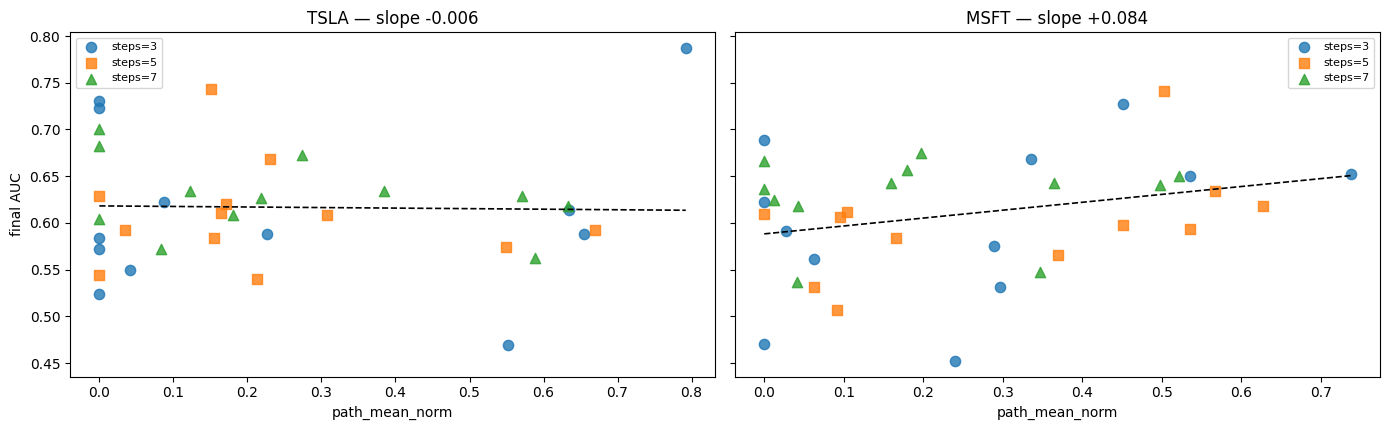

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
for ax, t in zip(axes, TICKERS):
    s = runs[runs.ticker == t]
    for st_, mk in [(3, "o"), (5, "s"), (7, "^")]:
        g = s[s.steps == st_]
        ax.scatter(g.path_mean_norm, g.final_auc, marker=mk, s=55, alpha=.8, label=f"steps={st_}")
    m, b = np.polyfit(s.path_mean_norm, s.final_auc, 1)
    xr = np.linspace(s.path_mean_norm.min(), s.path_mean_norm.max(), 40)
    ax.plot(xr, m * xr + b, "k--", lw=1.2)
    ax.set_title(f"{t} — slope {m:+.3f}")
    ax.set_xlabel("path_mean_norm"); ax.legend(fontsize=8)
axes[0].set_ylabel("final AUC")
plt.tight_layout(); plt.show()

Flat in both halves. Two independent 36-run designs agreeing on a null is much stronger
evidence than one, and this is the sweep's clearest replicated negative.

## D · Differential analysis by factor

The question is not which level wins but whether any level separates from the ordinary
scatter between runs.

In [14]:
tbl = []
for t in TICKERS:
    s = runs[runs.ticker == t]
    grand, sd = s.final_auc.mean(), s.final_auc.std()
    for f in FACTORS:
        for lvl, g in s.groupby(f):
            tbl.append({"ticker": t, "factor": f, "level": lvl, "n": len(g),
                        "mean AUC": round(g.final_auc.mean(), 4),
                        "SD": round(g.final_auc.std(), 4),
                        "dist from grand mean": round(abs(g.final_auc.mean() - grand), 4),
                        "in SD units": round(abs(g.final_auc.mean() - grand) / sd, 2)})
factor_tbl = pd.DataFrame(tbl)
factor_tbl.pivot_table(index=["factor", "level"], columns="ticker",
                       values="mean AUC").round(4)

ticker                           MSFT    TSLA
factor           level                       
chain_hops       3             0.6447  0.6266
                 4             0.5875  0.5885
                 5             0.5953  0.6352
evolution_prompt default       0.6169  0.6125
                 event_driven  0.6167  0.6384
                 fundamental   0.5939  0.5994
lookback_days    3             0.6240  0.6064
                 8             0.5737  0.5967
                 10            0.6177  0.6428
                 20            0.6212  0.6212
steps            3             0.5992  0.6125
                 5             0.6000  0.6091
                 7             0.6282  0.6287

In [15]:
for t in TICKERS:
    s = runs[runs.ticker == t]
    sub = factor_tbl[factor_tbl.ticker == t]
    worst = sub.loc[sub["dist from grand mean"].idxmax()]
    print(f"{t}: grand mean {s.final_auc.mean():.4f}  between-run SD {s.final_auc.std():.4f}")
    print(f"    largest factor deviation: {worst.factor}={worst.level} at {worst['mean AUC']:.4f} "
          f"({worst['dist from grand mean']:.4f}, {worst['in SD units']:.2f} SD)\n")

TSLA: grand mean 0.6168  between-run SD 0.0649
    largest factor deviation: chain_hops=4 at 0.5885 (0.0283, 0.44 SD)

MSFT: grand mean 0.6092  between-run SD 0.0640
    largest factor deviation: chain_hops=3 at 0.6447 (0.0355, 0.56 SD)



In [16]:
# Do the halves agree on which level is best / worst? This is the "agree?" column.
rows = []
for f in FACTORS:
    m = {t: runs[runs.ticker == t].groupby(f).final_auc.mean() for t in TICKERS}
    rows.append({
        "factor": f,
        "TSLA best": m["TSLA"].idxmax(), "MSFT best": m["MSFT"].idxmax(),
        "best agrees": m["TSLA"].idxmax() == m["MSFT"].idxmax(),
        "TSLA worst": m["TSLA"].idxmin(), "MSFT worst": m["MSFT"].idxmin(),
        "worst agrees": m["TSLA"].idxmin() == m["MSFT"].idxmin(),
    })
agree = pd.DataFrame(rows)
print(f"agree on best: {agree['best agrees'].sum()}/4   "
      f"agree on worst: {agree['worst agrees'].sum()}/4\n")
# MSFT's two leading prompts are a near-tie; idxmax picks one arbitrarily.
print("MSFT prompt means at full precision:")
print(runs[runs.ticker == "MSFT"].groupby("evolution_prompt").final_auc.mean().round(6))
agree

agree on best: 1/4   agree on worst: 3/4

MSFT prompt means at full precision:
evolution_prompt
default         0.616856
event_driven    0.616667
fundamental     0.593939
Name: final_auc, dtype: float64


,factor,TSLA best,MSFT best,best agrees,TSLA worst,MSFT worst,worst agrees
0,lookback_days,10,3,False,8,8,True
1,steps,7,7,True,5,3,False
2,chain_hops,5,3,False,4,4,True
3,evolution_prompt,event_driven,default,False,fundamental,fundamental,True


### How much of the variation do the factors explain?

The measure is **eta-squared**: the share of the spread in AUC that lines up with a factor.

- **denominator** `SS_total` — take all 36 runs, measure how far each AUC sits from the
  overall average, square, add up. One number for *how much the runs disagree in total*.
- **numerator** `SS_between` — replace each run by its group's average (every `hops=4` run
  becomes 0.5885, and so on), then measure how far those group averages sit from the
  overall average, square, weight by group size, add up. This is *the disagreement you
  could predict knowing only which level a run used*.

The ratio answers: if the only thing you knew about a run was its setting for this factor,
what share of the run-to-run variation could you account for?

In [17]:
# The intermediate sums of squares, not just the ratio.
rows = []
for t in TICKERS:
    s = runs[runs.ticker == t]
    gm = s.final_auc.mean()
    ss_total = ((s.final_auc - gm) ** 2).sum()
    for f in FACTORS:
        g = s.groupby(f).final_auc
        ss_between = (g.count() * (g.mean() - gm) ** 2).sum()
        rows.append({"half": t, "factor": f,
                     "SS_between (numerator)": round(ss_between, 6),
                     "SS_total (denominator)": round(ss_total, 6),
                     "eta^2": round(ss_between / ss_total, 3)})
pd.DataFrame(rows).set_index(["half", "factor"])

SS_between (numerator)  SS_total (denominator)  eta^2
half factor                                                                 
TSLA lookback_days                   0.010831                0.147422  0.073
     steps                           0.002641                0.147422  0.018
     chain_hops                      0.014844                0.147422  0.101
     evolution_prompt                0.009496                0.147422  0.064
MSFT lookback_days                   0.015232                0.143455  0.106
     steps                           0.006546                0.143455  0.046
     chain_hops                      0.023101                0.143455  0.161
     evolution_prompt                0.004167                0.143455  0.029

In [18]:
# Rolled up per half, with the residual. This is the report's table.
rows = []
for t in TICKERS:
    s = runs[runs.ticker == t]
    total_ss = ((s.final_auc - s.final_auc.mean()) ** 2).sum()
    r = {"ticker": t}
    explained = 0.0
    for f in FACTORS:
        gm = s.groupby(f).final_auc
        between = (gm.count() * (gm.mean() - s.final_auc.mean()) ** 2).sum()
        r[f] = round(between / total_ss, 3)
        explained += between / total_ss
    r["all four combined"] = round(explained, 3)
    r["residual"] = round(1 - explained, 3)
    rows.append(r)
pd.DataFrame(rows)

,ticker,lookback_days,steps,chain_hops,evolution_prompt,all four combined,residual
0,TSLA,0.073,0.018,0.101,0.064,0.256,0.744
1,MSFT,0.106,0.046,0.161,0.029,0.342,0.658


**Why the four shares may be added.** Summing eta-squared values is normally invalid —
factors usually share variance, so you would double-count. It is legitimate here only
because the orthogonal array makes the factors exactly uncorrelated. Worth verifying
rather than assuming: fit one joint model with dummies for every level of every factor and
compare its R-squared against the naive sum.

In [19]:
for t in TICKERS:
    s = runs[runs.ticker == t]
    gm = s.final_auc.mean()
    ss_total = ((s.final_auc - gm) ** 2).sum()
    naive = sum((s.groupby(f).final_auc.count() *
                 (s.groupby(f).final_auc.mean() - gm) ** 2).sum() / ss_total
                for f in FACTORS)
    X = pd.get_dummies(s[FACTORS].astype(str), drop_first=True).astype(float)
    X.insert(0, "const", 1.0)
    y = s.final_auc.values
    beta, *_ = np.linalg.lstsq(X.values, y, rcond=None)
    r2 = 1 - ((y - X.values @ beta) ** 2).sum() / ss_total
    print(f"{t}: sum of individual eta^2 = {naive:.4f}   joint model R^2 = {r2:.4f}   "
          f"difference = {abs(naive - r2):.1e}")
print()
print("Agreement to machine precision confirms the design is orthogonal, so the")
print("per-factor shares partition the variance without overlap.")

TSLA: sum of individual eta^2 = 0.2565   joint model R^2 = 0.2565   difference = 1.1e-16
MSFT: sum of individual eta^2 = 0.3419   joint model R^2 = 0.3419   difference = 1.7e-16

Agreement to machine precision confirms the design is orthogonal, so the
per-factor shares partition the variance without overlap.


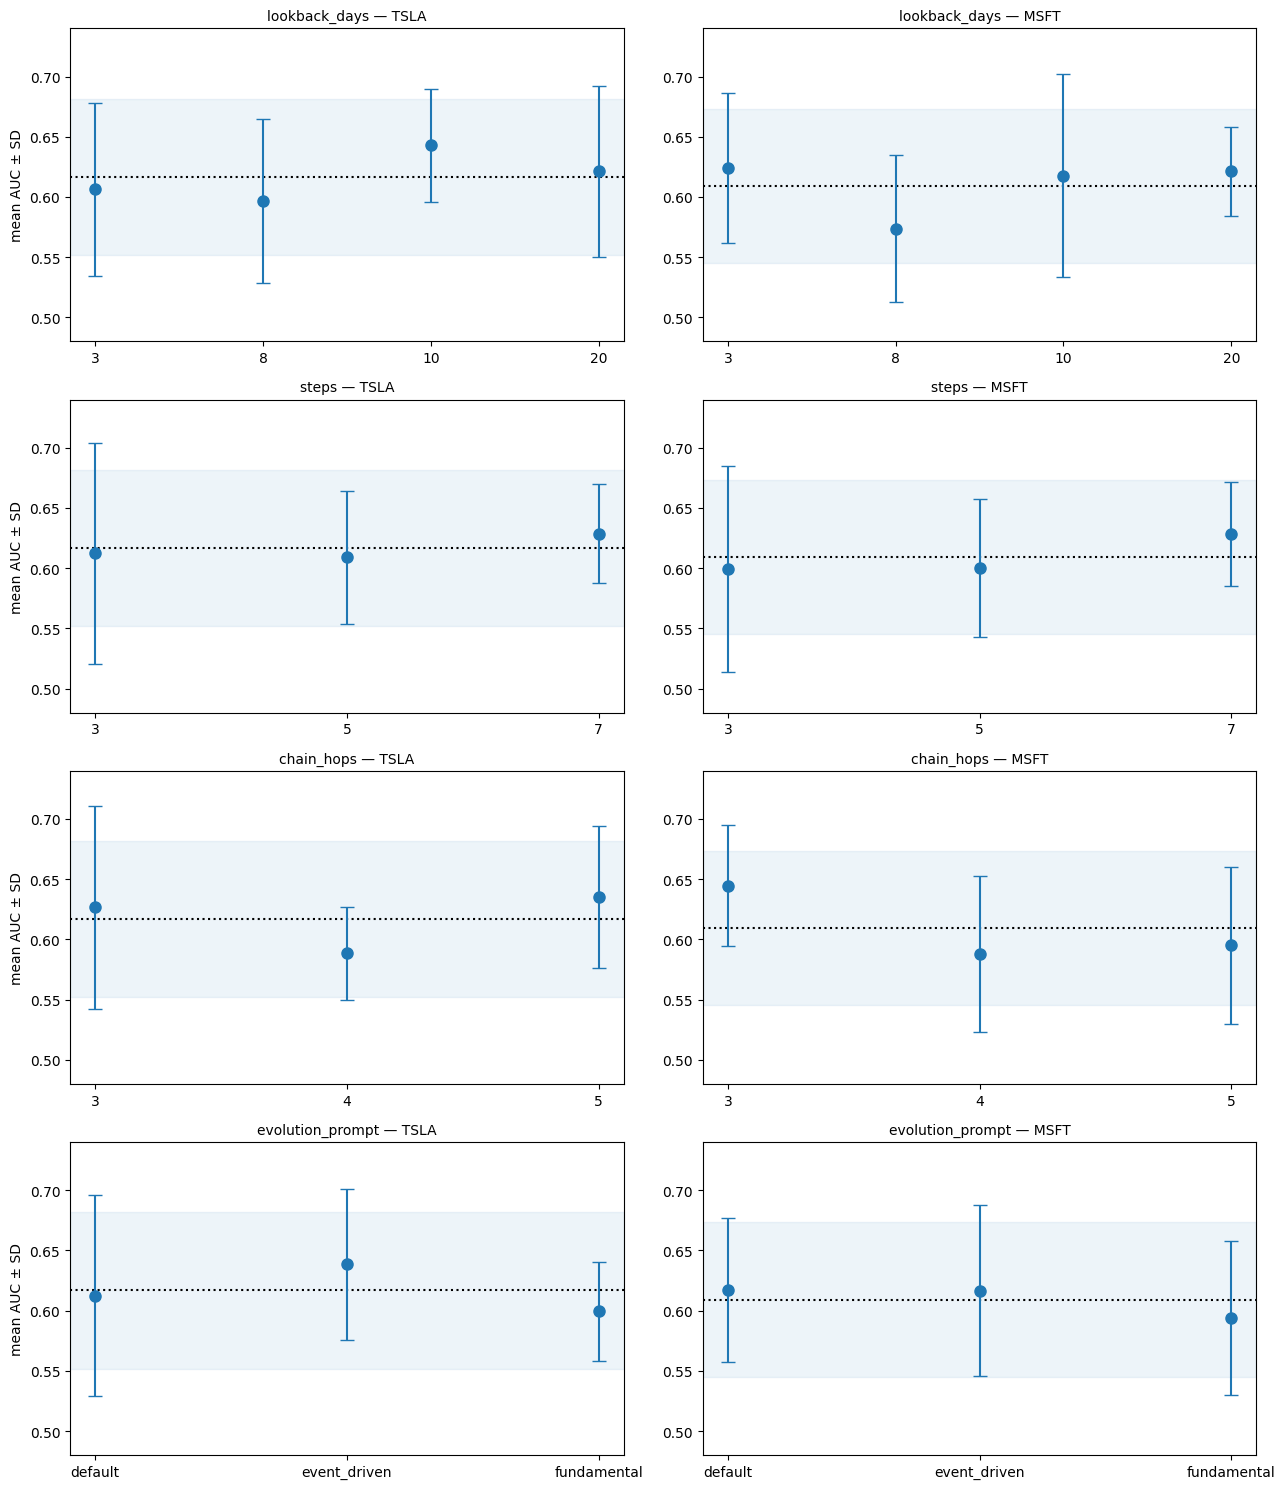

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(13, 15))
for row, f in enumerate(FACTORS):
    for col, t in enumerate(TICKERS):
        ax = axes[row][col]
        s = runs[runs.ticker == t]
        grand, sd = s.final_auc.mean(), s.final_auc.std()
        g = s.groupby(f).final_auc
        levels = list(g.groups)
        ax.axhspan(grand - sd, grand + sd, color="tab:blue", alpha=.08)
        ax.axhline(grand, ls=":", color="k")
        ax.errorbar(range(len(levels)), g.mean(), yerr=g.std(), fmt="o", ms=8, capsize=5)
        ax.set_xticks(range(len(levels))); ax.set_xticklabels(levels)
        ax.set_title(f"{f} — {t}", fontsize=10)
        ax.set_ylim(0.48, 0.74)
        if col == 0:
            ax.set_ylabel("mean AUC ± SD")
plt.tight_layout(); plt.show()

Every level sits inside its own ticker's ±1 SD band, in both halves. The factors jointly
explain a minority of the variance; the rest is run-to-run noise.

### Does running more steps keep helping?

Two lines, one question.

- **best found so far** accumulates — it is a maximum over a growing pool, so it rises
  whether or not the proposals improve.
- **mean candidate at this step** does not accumulate. It rises only if the candidates
  themselves are getting better.

If the first climbs while the second stays flat, the improvement is more draws rather than
better draws.

In [21]:
def running_max_curve(df):
    """Per run, the best candidate AUC seen up to and including each step."""
    out = {}
    for rid, g in df.groupby("run_id"):
        best, cur = {}, -np.inf
        for s_ in sorted(g.step.unique()):
            cur = max(cur, g.loc[g.step == s_, "auc"].max())
            best[s_] = cur
        out[rid] = best
    return pd.DataFrame(out).T


rows = []
for t in TICKERS:
    a = adds[adds.ticker == t]
    per_step = a.groupby("step").auc.mean()          # candidates proposed AT that step
    running = running_max_curve(a).mean()            # best reached BY that step
    n = running_max_curve(a).notna().sum()
    rows.append(pd.DataFrame({
        "n runs": n,
        "mean candidate at step": per_step.round(4),
        "best found so far": running.round(4),
    }))
step_tbl = pd.concat(rows, keys=TICKERS, names=["half", "step"])
step_tbl

n runs  mean candidate at step  best found so far
half step                                                   
TSLA 1         36                  0.5194             0.5758
     2         36                  0.5040             0.6008
     3         36                  0.4813             0.6035
     4         24                  0.4852             0.6047
     5         24                  0.4962             0.6091
     6         12                  0.4970             0.6257
     7         12                  0.5070             0.6287
MSFT 1         36                  0.4840             0.5225
     2         36                  0.4985             0.5670
     3         36                  0.4961             0.5933
     4         24                  0.4753             0.5954
     5         24                  0.5111             0.6054
     6         12                  0.5095             0.6193
     7         12                  0.5130             0.6282

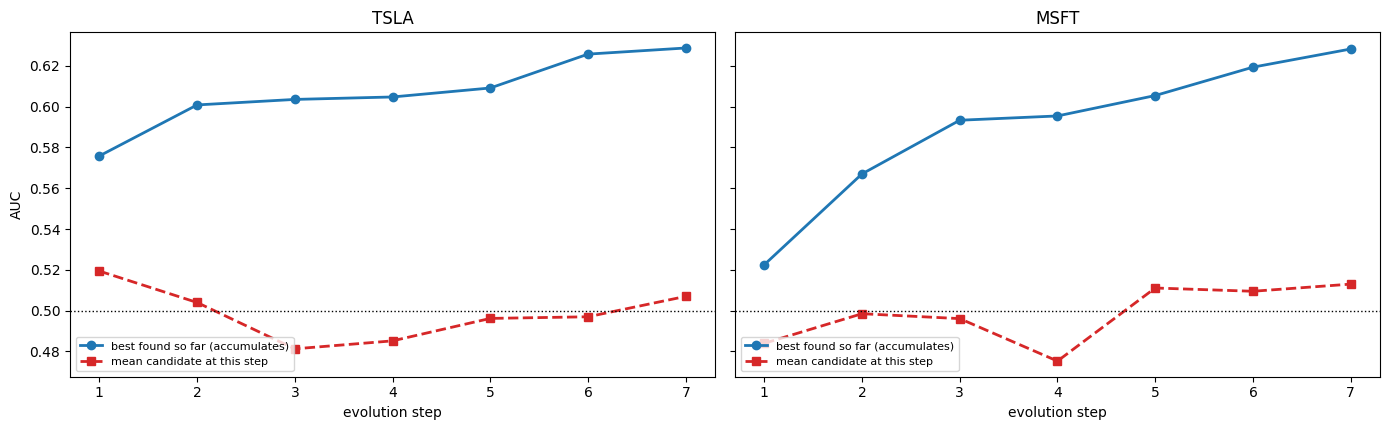

TSLA: best-so-far 0.576 -> 0.629   |   mean candidate 0.481-0.519 (flat, near chance)
MSFT: best-so-far 0.522 -> 0.628   |   mean candidate 0.475-0.513 (flat, near chance)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
for ax, t in zip(axes, TICKERS):
    c = step_tbl.loc[t]
    ax.plot(c.index, c["best found so far"], "o-", lw=2,
            label="best found so far (accumulates)")
    ax.plot(c.index, c["mean candidate at step"], "s--", color="tab:red", lw=2,
            label="mean candidate at this step")
    ax.axhline(0.5, ls=":", color="k", lw=1)
    ax.set_title(t); ax.set_xlabel("evolution step")
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("AUC")
plt.tight_layout(); plt.show()

for t in TICKERS:
    c = step_tbl.loc[t]
    print(f"{t}: best-so-far {c['best found so far'].iloc[0]:.3f} -> "
          f"{c['best found so far'].iloc[-1]:.3f}   |   mean candidate "
          f"{c['mean candidate at step'].min():.3f}-{c['mean candidate at step'].max():.3f} "
          f"(flat, near chance)")

The best-so-far climbs by about 0.05 in both halves while candidate quality stays flat
near 0.5. Evolution is not proposing better ontologies as it goes — it is proposing more of
them, and the maximum of a larger pool is naturally higher.

This bears on cost: `steps=7` takes roughly 1.4× the compute of `steps=3` for candidates
that are no better.

One caveat on reading the left-hand line: the run set shrinks as steps advance (36 runs
reach step 3, only the 12 `steps=7` runs reach step 7), and those surviving runs score
higher, so part of its rise is survivorship rather than accumulation.

## E · Ontology-change analysis

Each candidate proposes **one node type and one relationship together**, so the (node,
relationship) pair is the unit of intervention — not the node.

In [23]:
counts = pd.DataFrame([{
    "ticker": t,
    "addition records": int((adds.ticker == t).sum()),
    "node types": adds[adds.ticker == t].node.nunique(),
    "distinct (node, rel) pairs": adds[adds.ticker == t].groupby(["node", "relationship"]).ngroups,
    "accepted": int(((adds.ticker == t) & (adds.status == "accepted")).sum()),
} for t in TICKERS])
# groupby drops null keys, so a candidate proposing a node with NO relationship is
# invisible above. The pair framing assumes that cannot happen — check it.
missing = adds[adds.relationship.isna() | adds.node.isna()]
print(f"candidates with a null node or relationship: {len(missing)} of {len(adds)}")
if len(missing):
    print(missing[["ticker", "step", "node", "relationship", "auc", "status"]].to_string(index=False))
counts

candidates with a null node or relationship: 1 of 720
ticker  step           node relationship      auc   status
  MSFT     5 RegulatoryBody          NaN 0.545455 rejected


,ticker,addition records,node types,"distinct (node, rel) pairs",accepted
0,TSLA,360,32,80,66
1,MSFT,360,37,90,90


### Why an addition cannot be scored against the run's current best

The gate makes the reference the *running maximum*, so a candidate is judged partly on how
lucky its own run's step 1 happened to be. The reference climbs while candidate quality
stays flat, and the share scored "negative" grows for that reason alone.

In [24]:
adds["reference"] = adds.auc - adds.delta_auc
bias = adds.dropna(subset=["delta_auc"]).groupby(["ticker", "step"]).agg(
    n=("auc", "size"),
    mean_candidate_auc=("auc", "mean"),
    mean_reference=("reference", "mean"),
    pct_negative=("delta_auc", lambda s: 100 * (s < 0).mean()),
).round(3)
bias

n  mean_candidate_auc  mean_reference  pct_negative
ticker step                                                      
MSFT   1     72               0.484           0.565        73.611
       2     72               0.499           0.523        62.500
       3     72               0.496           0.567        76.389
       4     48               0.475           0.590        85.417
       5     48               0.511           0.595        85.417
       6     24               0.509           0.611        91.667
       7     24               0.513           0.619        79.167
TSLA   1     72               0.519           0.563        62.500
       2     72               0.504           0.576        80.556
       3     72               0.481           0.601        93.056
       4     48               0.485           0.599        87.500
       5     48               0.496           0.605        91.667
       6     24               0.497           0.609        83.333
       7     24               0.507           0.626        87.500

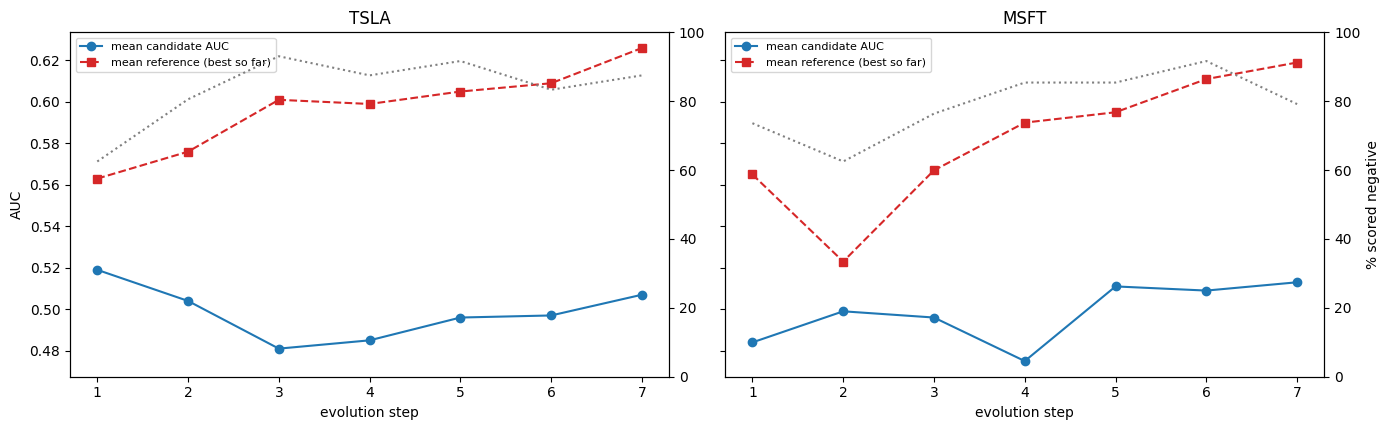

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
for ax, t in zip(axes, TICKERS):
    b = bias.loc[t]
    ax.plot(b.index, b.mean_candidate_auc, "o-", label="mean candidate AUC")
    ax.plot(b.index, b.mean_reference, "s--", color="tab:red", label="mean reference (best so far)")
    ax.set_title(t); ax.set_xlabel("evolution step"); ax.legend(fontsize=8)
    ax2 = ax.twinx(); ax2.plot(b.index, b.pct_negative, ":", color="gray")
    ax2.set_ylim(0, 100)
    if t == "MSFT":
        ax2.set_ylabel("% scored negative")
axes[0].set_ylabel("AUC")
plt.tight_layout(); plt.show()

### The reference-free measure: win rate

Both candidates in a step are built on the same graph and scored on the same days, so
which one wins carries no reference bias. At 42 validation days the *size* of a gap is
not worth reading — only its sign. Win rate averages 50% by construction: it ranks
additions against each other and says nothing about whether additions help at all.

In [26]:
# Within each (run, step), the higher AUC wins; ties count for neither. Round first —
# one MSFT step has two candidates differing by a single ULP, which is bit noise from
# the AUC computation rather than a win.
adds["auc_r"] = adds.auc.round(9)
adds["won_recomputed"] = False
for _, g in adds.groupby(["run_id", "step"]):
    top = g.auc_r.max()
    if (g.auc_r == top).sum() == 1:
        adds.loc[g.index[g.auc_r == top], "won_recomputed"] = True
assert (adds.won_recomputed == adds.won).all(), "recomputation disagrees with pull script"
print(f"win flags reproduced exactly: {len(adds)} records")

wins = (adds.dropna(subset=["delta_auc"])
        .groupby(["ticker", "node", "relationship"])
        .agg(proposed=("won", "size"), won=("won", "sum")))
wins["win_rate_%"] = (100 * wins.won / wins.proposed).round(0)
wins = wins[wins.proposed >= 8].sort_values(["ticker", "win_rate_%"], ascending=[True, False])
wins

win flags reproduced exactly: 720 records


proposed  won  win_rate_%
ticker node                   relationship                                               
MSFT   LegalAction            INVOLVES_LEGAL_ACTION                    9    6        67.0
       MarketEvent            TRIGGERS                                11    7        64.0
       GeographicRegion       LOCATED_IN                              24   15        62.0
       RegulatoryAnnouncement MENTIONS_REGULATORY_ANNOUNCEMENT        13    8        62.0
                              ANNOUNCED_BY                             9    5        56.0
       Industry               OPERATES_IN                             13    7        54.0
       RegulatoryBody         MENTIONS_REGULATORY_BODY                26   14        54.0
                              ISSUED_BY                                8    4        50.0
       EconomicIndicator      REFERENCES                              36   17        47.0
       Executive              MENTIONS_EXECUTIVE                      12    5        42.0
       CreditRating           HAS_CREDIT_RATING                       33   13        39.0
       MarketIndex            MENTIONS_MARKET_INDEX                    8    3        38.0
       EarningsReport         HAS_EARNINGS_REPORT                     12    4        33.0
       CorporateAction        TRIGGERS                                11    3        27.0
       Product                MENTIONS_PRODUCT                         9    2        22.0
TSLA   RegulatoryBody         MENTIONS_REGULATORY_BODY                27   21        78.0
                              ISSUED_BY                                8    6        75.0
       Product                MENTIONS_PRODUCT                        11    8        73.0
       MarketEvent            TRIGGERS                                10    6        60.0
       CreditRating           HAS_CREDIT_RATING                       35   19        54.0
       Executive              MENTIONS_EXECUTIVE                      12    6        50.0
       MarketIndex            MENTIONS_MARKET_INDEX                   12    6        50.0
       RegulatoryAnnouncement MENTIONS_REGULATORY_ANNOUNCEMENT         8    4        50.0
       GeographicRegion       LOCATED_IN                              25   11        44.0
       LegalAction            INVOLVES_LEGAL_ACTION                    9    4        44.0
       Industry               OPERATES_IN                             17    6        35.0
       EarningsReport         HAS_EARNINGS_REPORT                     12    4        33.0
       EconomicIndicator      REFERENCES                              36    8        22.0

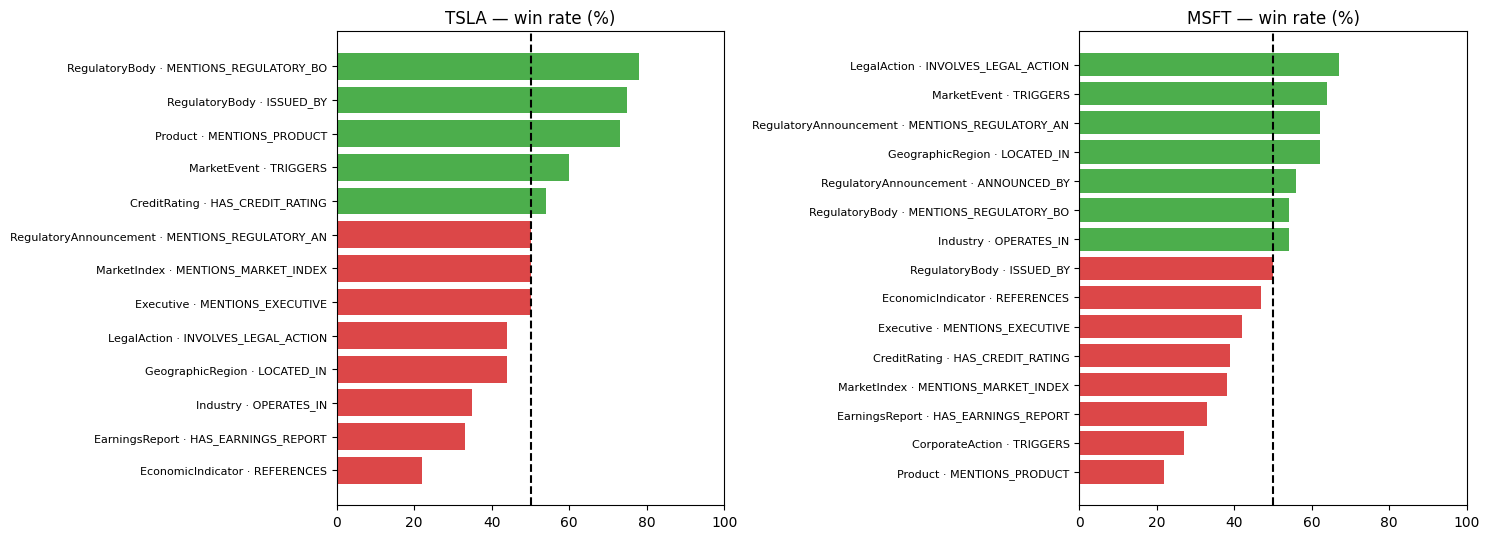

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, t in zip(axes, TICKERS):
    w = wins.loc[t].sort_values("win_rate_%")
    labels = [f"{n} · {r[:22]}" for n, r in w.index]
    ax.barh(range(len(w)), w["win_rate_%"],
            color=np.where(w["win_rate_%"] > 50, "tab:green", "tab:red"), alpha=.85)
    ax.axvline(50, ls="--", color="k")
    ax.set_yticks(range(len(w))); ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(f"{t} — win rate (%)"); ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()

In [28]:
# Do the two halves agree on which additions are good? Only pairs common to both.
common = wins.reset_index().pivot_table(index=["node", "relationship"],
                                        columns="ticker", values="win_rate_%").dropna()
rho, p = stats.spearmanr(common.TSLA, common.MSFT)
print(f"{len(common)} pairs proposed >=8 times in BOTH halves")
print(f"Spearman rho between TSLA and MSFT win rates: {rho:+.3f}  (p = {p:.3f})")
common.astype(int)

13 pairs proposed >=8 times in BOTH halves
Spearman rho between TSLA and MSFT win rates: -0.026  (p = 0.932)


,ticker,MSFT,TSLA
node,relationship,,
CreditRating,HAS_CREDIT_RATING,39,54
EarningsReport,HAS_EARNINGS_REPORT,33,33
EconomicIndicator,REFERENCES,47,22
Executive,MENTIONS_EXECUTIVE,42,50
GeographicRegion,LOCATED_IN,62,44
Industry,OPERATES_IN,54,35
LegalAction,INVOLVES_LEGAL_ACTION,67,44
MarketEvent,TRIGGERS,64,60
MarketIndex,MENTIONS_MARKET_INDEX,38,50


TSLA: step 1 50%, steps 2+ range 6-15%
MSFT: step 1 50%, steps 2+ range 8-31%


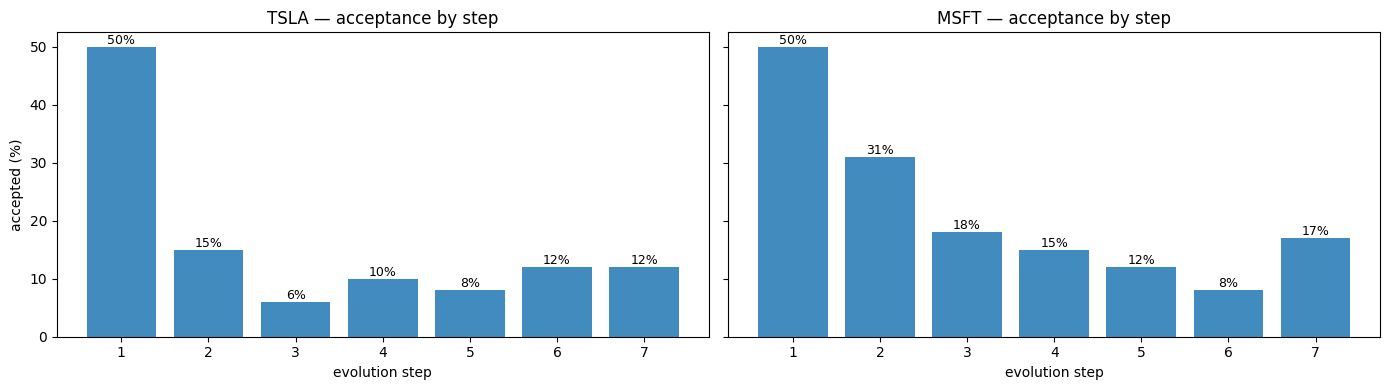

proposed  accepted  accept_%
ticker step                              
MSFT   1           72        36      50.0
       2           72        22      31.0
       3           72        13      18.0
       4           48         7      15.0
       5           48         6      12.0
       6           24         2       8.0
       7           24         4      17.0
TSLA   1           72        36      50.0
       2           72        11      15.0
       3           72         4       6.0
       4           48         5      10.0
       5           48         4       8.0
       6           24         3      12.0
       7           24         3      12.0

In [29]:
acc = adds.groupby(["ticker", "step"]).agg(
    proposed=("status", "size"),
    accepted=("status", lambda s: (s == "accepted").sum()),
)
acc["accept_%"] = (100 * acc.accepted / acc.proposed).round(0)
for t in TICKERS:
    a = acc.loc[t]
    print(f"{t}: step 1 {a.loc[1,'accept_%']:.0f}%, steps 2+ range "
          f"{a.loc[2:,'accept_%'].min():.0f}-{a.loc[2:,'accept_%'].max():.0f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, t in zip(axes, TICKERS):
    a = acc.loc[t]
    ax.bar(a.index, a["accept_%"], alpha=.85)
    for s, v in zip(a.index, a["accept_%"]):
        ax.annotate(f"{v:.0f}%", (s, v), ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{t} — acceptance by step"); ax.set_xlabel("evolution step")
axes[0].set_ylabel("accepted (%)")
plt.tight_layout(); plt.show()
acc

In [30]:
# Gate selectivity: does the gate accept the additions that actually scored better?
gate = adds.dropna(subset=["delta_auc"]).assign(acc=lambda d: d.status == "accepted")
sel = gate.groupby("ticker").apply(lambda g: pd.Series({
    "accepted": f"{int(g.acc.sum())} / {len(g)} ({100*g.acc.mean():.1f}%)",
    "mean delta of accepted": round(g[g.acc].delta_auc.mean(), 4),
    "mean delta of rejected": round(g[~g.acc].delta_auc.mean(), 4),
}), include_groups=False)
sel

,accepted,mean delta of accepted,mean delta of rejected
ticker,,,
MSFT,90 / 360 (25.0%),0.0178,-0.1067
TSLA,66 / 360 (18.3%),0.0294,-0.1192


In [31]:
# Cost of extra evolution steps — the claim in the report's cost paragraph.
for t in TICKERS:
    m = runs[runs.ticker == t].groupby("steps").final_auc.mean()
    print(f"{t}: steps7 - steps3 = {m[7]-m[3]:+.4f}   "
          f"mean(steps5,7) - steps3 = {(m[5]+m[7])/2 - m[3]:+.4f}   "
          f"(between-run SD {runs[runs.ticker==t].final_auc.std():.3f})")

TSLA: steps7 - steps3 = +0.0162   mean(steps5,7) - steps3 = +0.0064   (between-run SD 0.065)
MSFT: steps7 - steps3 = +0.0290   mean(steps5,7) - steps3 = +0.0149   (between-run SD 0.064)


## F · Train vs validation — the memorisation check

`train_auc` was added on 2026-08-11, so it exists for every MSFT run and for no TSLA run.
This is the one place the two halves cannot be shown side by side, and the MSFT column
alone settles the question.

In [32]:
tr = runs.dropna(subset=["train_auc"])
print(f"runs with train_auc logged: {len(tr)} ({tr.ticker.unique().tolist()})")
print(f"  train AUC   mean {tr.train_auc.mean():.4f}   min {tr.train_auc.min():.4f}   "
      f"max {tr.train_auc.max():.4f}   SD {tr.train_auc.std():.4f}")
print(f"  val AUC     mean {tr.final_auc.mean():.4f}")
print(f"  gap         mean {(tr.train_auc - tr.final_auc).mean():+.4f}")
print()
print("488 structural features against 98 training days: the model separates the training")
print("set perfectly in every single run, with zero variance. Whatever the validation AUC")
print("is measuring, it is not a model that had to generalise to fit.")

runs with train_auc logged: 36 (['MSFT'])
  train AUC   mean 1.0000   min 1.0000   max 1.0000   SD 0.0000
  val AUC     mean 0.6092
  gap         mean +0.3908

488 structural features against 98 training days: the model separates the training
set perfectly in every single run, with zero variance. Whatever the validation AUC
is measuring, it is not a model that had to generalise to fit.


## G · Which differences survive a test

Everything above is descriptive. This section asks which of those differences hold up
under a formal test, and produces the summary table in the report's section G.

The **run is the unit of analysis** — 36 per half — so nothing rests on the precision of a
single AUC: the ANOVA and Welch tests take their error term from the observed run-to-run
scatter, the sign test from win counts alone.

In [33]:
# 1. Does the graph arm beat text? Paired within run, so a sign test on the 36 lifts.
sign = {t: stats.binomtest(int((runs[runs.ticker == t].delta > 0).sum()), 36, 0.5).pvalue
        for t in TICKERS}
sign["pooled"] = stats.binomtest(int((runs.delta > 0).sum()), 72, 0.5).pvalue

# 2. Does any hyperparameter matter? One-way ANOVA per factor; the balanced design
#    means the other three factors are distributed identically across levels.
anova = pd.DataFrame([
    {"half": t, "factor": f,
     **dict(zip(["F", "p"], stats.f_oneway(
         *[g.final_auc.values for _, g in runs[runs.ticker == t].groupby(f)])))}
    for t in TICKERS for f in FACTORS])

# 2b. Same question without assuming normality.
kw = pd.DataFrame([
    {"half": t, "factor": f,
     **dict(zip(["H", "p"], stats.kruskal(
         *[g.final_auc.values for _, g in runs[runs.ticker == t].groupby(f)])))}
    for t in TICKERS for f in FACTORS])

# 3. Path features: correlation, and empty vs non-empty block.
path_p = []
for t in TICKERS:
    s_ = runs[runs.ticker == t]
    path_p.append(stats.spearmanr(s_.path_mean_norm, s_.final_auc)[1])
    path_p.append(stats.ttest_ind(s_[s_.path_mean_norm == 0].final_auc,
                                  s_[s_.path_mean_norm > 0].final_auc, equal_var=False)[1])

# 4. Did filtering the corpus change the lift? Unpaired, between halves.
corpus_p = stats.ttest_ind(runs[runs.ticker == "MSFT"].delta,
                           runs[runs.ticker == "TSLA"].delta, equal_var=False)[1]

# 5. Does the addition ranking replicate across halves?
w = (adds.dropna(subset=["delta_auc"]).groupby(["ticker", "node", "relationship"])
        .agg(n=("won", "size"), wins=("won", "sum")))
w = w[w.n >= 8].assign(rate=lambda d: 100 * d.wins / d.n)
common = (w.reset_index().pivot_table(index=["node", "relationship"],
                                      columns="ticker", values="rate").dropna())
rho_replic, p_replic = stats.spearmanr(common.TSLA, common.MSFT)

# 6. Does the gate discriminate? Circular by construction — included as a warning.
gate_p = min(stats.ttest_ind(
    adds[(adds.ticker == t) & (adds.status == "accepted")].delta_auc.dropna(),
    adds[(adds.ticker == t) & (adds.status != "accepted")].delta_auc.dropna(),
    equal_var=False)[1] for t in TICKERS)

print(f"ANOVA: {(anova.p < 0.05).sum()} of {len(anova)} significant at 0.05 "
      f"(Bonferroni threshold {0.05/len(anova):.4f})")
print(f"Kruskal-Wallis: {(kw.p < 0.05).sum()} of {len(kw)} significant")
print(f"addition ranking: rho {rho_replic:+.3f} over {len(common)} pairs common to both halves")

ANOVA: 0 of 8 significant at 0.05 (Bonferroni threshold 0.0063)
Kruskal-Wallis: 0 of 8 significant
addition ranking: rho -0.028 over 13 pairs common to both halves


In [34]:
summary = pd.DataFrame([
    ("graph beats text — TSLA", "sign test, 28/36", f"{sign['TSLA']:.4f}", "YES"),
    ("graph beats text — MSFT", "sign test, 28/36", f"{sign['MSFT']:.4f}", "YES"),
    ("graph beats text — pooled", "sign test, 56/72", f"{sign['pooled']:.1e}", "YES"),
    ("hyperparameters (8 tests)", "one-way ANOVA", f"min {anova.p.min():.3f}", "no"),
    ("hyperparameters (8 tests)", "Kruskal-Wallis", f"min {kw.p.min():.3f}", "no"),
    ("path features", "Spearman / Welch t", f"{min(path_p):.2f} - {max(path_p):.2f}", "no"),
    ("corpus filtering", "Welch t", f"{corpus_p:.2f}", "no"),
    ("addition ranking replicates", "Spearman across halves", f"{p_replic:.2f}", "no"),
    ("gate discriminates", "Welch t", f"{gate_p:.0e}", "yes, but circular"),
], columns=["question", "test", "p", "significant?"])
summary.set_index("question")

,test,p,significant?
question,,,
graph beats text — TSLA,"sign test, 28/36",0.0012,YES
graph beats text — MSFT,"sign test, 28/36",0.0012,YES
graph beats text — pooled,"sign test, 56/72",2.4e-06,YES
hyperparameters (8 tests),one-way ANOVA,min 0.055,no
hyperparameters (8 tests),Kruskal-Wallis,min 0.094,no
path features,Spearman / Welch t,0.20 - 0.96,no
corpus filtering,Welch t,0.61,no
addition ranking replicates,Spearman across halves,0.93,no
gate discriminates,Welch t,9e-27,"yes, but circular"


**One real positive result, replicated.** The graph arm beats the text baseline 28 of 36
times in each half independently — and the replication matters more than any p-value, since
two halves with different labels, different corpora and independently drawn ontologies
landed on the same count.

Everything else is null, and these are reasonably well-powered nulls: each rests on two
balanced 36-run designs that agree.

Two rows need care:

- **The gate result is significant and meaningless.** The gate accepts a candidate exactly
  when its `delta_auc` clears a threshold, so testing whether accepted candidates have
  higher `delta_auc` tests the definition of the gate, not the ontology.
- **The within-half p-values are optimistic.** The 36 runs share validation days, and all 9
  runs at a given lookback share one text baseline — only four distinct baselines per half —
  so they are not independent.

## G · The cross-ticker verdict

The MSFT half was run specifically to test whether the mixed corpus was diluting the
signal. It was not.

In [35]:
verdict = pd.DataFrame({
    t: {
        "mean final AUC": round(runs[runs.ticker == t].final_auc.mean(), 4),
        "mean text baseline": round(runs[runs.ticker == t].baseline_auc.mean(), 4),
        "mean lift": round(runs[runs.ticker == t].delta.mean(), 4),
        "beat baseline": f"{(runs[runs.ticker == t].delta > 0).sum()}/36",
        "best run": round(runs[runs.ticker == t].final_auc.max(), 4),
        "path-signal slope": round(
            np.polyfit(runs[runs.ticker == t].path_mean_norm,
                       runs[runs.ticker == t].final_auc, 1)[0], 4),
    } for t in TICKERS
})
verdict["difference"] = ""
for k in ["mean final AUC", "mean text baseline", "mean lift"]:
    verdict.loc[k, "difference"] = f"{verdict.loc[k, 'MSFT'] - verdict.loc[k, 'TSLA']:+.4f}"
verdict

,TSLA,MSFT,difference
mean final AUC,0.6168,0.6092,-0.0076
mean text baseline,0.5629,0.5648,+0.0019
mean lift,0.0538,0.0444,-0.0094
beat baseline,28/36,28/36,
best run,0.7872,0.7409,
path-signal slope,-0.0059,0.0845,


In [36]:
gap = runs[runs.ticker == "MSFT"].delta.mean() - runs[runs.ticker == "TSLA"].delta.mean()
sd = runs.groupby("ticker").final_auc.std().mean()
print(f"difference in mean lift (MSFT - TSLA): {gap:+.4f}")
print(f"  against a between-run SD of {sd:.4f}, i.e. {abs(gap)/sd:.2f} of the ordinary")
print(f"  scatter between runs within a half")
print()
print("Both halves beat their baseline in exactly 28 of 36 runs. Filtering the corpus to")
print("the labelled company moved nothing that this design can resolve.")

difference in mean lift (MSFT - TSLA): -0.0095
  against a between-run SD of 0.0645, i.e. 0.15 of the ordinary
  scatter between runs within a half

Both halves beat their baseline in exactly 28 of 36 runs. Filtering the corpus to
the labelled company moved nothing that this design can resolve.


### Cross-check: every figure quoted in the report

One cell, one line per number that appears in
`analyses/tsla_msft_200days_report.html`, so each can be ticked off against its source.

In [37]:
def eta2_total(s):
    """Share of a half's AUC variance explained by the four factors jointly."""
    total = ((s.final_auc - s.final_auc.mean()) ** 2).sum()
    between = sum((g.count() * (g.mean() - s.final_auc.mean()) ** 2).sum()
                  for g in (s.groupby(f).final_auc for f in FACTORS))
    return between / total


def per_ticker(fn):
    """Apply fn to each half's runs+additions, returning a {ticker: value} dict."""
    return {t: fn(runs[runs.ticker == t], adds[adds.ticker == t]) for t in TICKERS}


checks = {
    "runs":                       per_ticker(lambda r, a: len(r)),
    "mean final AUC":             per_ticker(lambda r, a: f"{r.final_auc.mean():.3f}"),
    "SD of final AUC":            per_ticker(lambda r, a: f"{r.final_auc.std():.3f}"),
    "min / max final AUC":        per_ticker(lambda r, a: f"{r.final_auc.min():.3f} / {r.final_auc.max():.3f}"),
    "mean text baseline":         per_ticker(lambda r, a: f"{r.baseline_auc.mean():.3f}"),
    "SD of text baseline":        per_ticker(lambda r, a: f"{r.baseline_auc.std():.3f}"),
    "mean lift":                  per_ticker(lambda r, a: f"{r.delta.mean():+.3f}"),
    "SD of lift":                 per_ticker(lambda r, a: f"{r.delta.std():.3f}"),
    "min / max lift":             per_ticker(lambda r, a: f"{r.delta.min():+.3f} / {r.delta.max():+.3f}"),
    "beat text baseline":         per_ticker(lambda r, a: f"{(r.delta > 0).sum()} / 36"),
    "mean Brier":                 per_ticker(lambda r, a: f"{r.brier_score.mean():.3f}"),
    "between-run SD of AUC":      per_ticker(lambda r, a: f"{r.final_auc.std():.3f}"),
    "path: Spearman rho":         per_ticker(lambda r, a: f"{stats.spearmanr(r.path_mean_norm, r.final_auc)[0]:+.3f}"),
    "path: OLS slope":            per_ticker(lambda r, a: f"{np.polyfit(r.path_mean_norm, r.final_auc, 1)[0]:+.3f}"),
    "path: empty blocks":         per_ticker(lambda r, a: f"{int((r.path_mean_norm == 0).sum())} / 36"),
    "furthest factor level":      per_ticker(lambda r, a: f"{max(abs(r.groupby(f).final_auc.mean() - r.final_auc.mean()).max() for f in FACTORS):.3f}"),
    "variance explained (4 factors)": per_ticker(lambda r, a: f"{eta2_total(r):.3f}"),
    "steps7 - steps3 AUC":        per_ticker(lambda r, a: f"{r.groupby('steps').final_auc.mean()[7] - r.groupby('steps').final_auc.mean()[3]:+.3f}"),
    "addition records":           per_ticker(lambda r, a: len(a)),
    "node types":                 per_ticker(lambda r, a: a.node.nunique()),
    "distinct (node, rel) pairs": per_ticker(lambda r, a: a.groupby(["node", "relationship"]).ngroups),
    "additions accepted":         per_ticker(lambda r, a: f"{(a.status == 'accepted').sum()} / {len(a)}"),
    "train AUC (mean)":           per_ticker(lambda r, a: f"{r.train_auc.mean():.4f}" if r.train_auc.notna().any() else "not logged"),
}
cross = pd.DataFrame(checks).T[TICKERS]

print("cross-half quantities (single-valued):")
print(f"  MSFT - TSLA lift gap        {gap:+.4f}")
print(f"  win-rate rank correlation   rho {rho:+.3f} over {len(common)} pairs")
print(f"  candidates with null rel.   {len(missing)} of {len(adds)}\n")
cross

cross-half quantities (single-valued):
  MSFT - TSLA lift gap        -0.0095
  win-rate rank correlation   rho -0.026 over 13 pairs
  candidates with null rel.   1 of 720



,TSLA,MSFT
runs,36,36
mean final AUC,0.617,0.609
SD of final AUC,0.065,0.064
min / max final AUC,0.469 / 0.787,0.452 / 0.741
mean text baseline,0.563,0.565
SD of text baseline,0.053,0.027
mean lift,+0.054,+0.044
SD of lift,0.084,0.070
min / max lift,-0.126 / +0.265,-0.150 / +0.200
beat text baseline,28 / 36,28 / 36


### What that buys

A well-powered negative on the corpus-dilution hypothesis, replicated across two
independent balanced designs:

- **Path-chain features do nothing** — flat dose–response in both halves
- **No hyperparameter separates** from between-run scatter in either half
- **Filtering the corpus changes nothing** — 28/36 both ways, mean lift differing by 0.010
- **The model memorises completely** — train AUC 1.0000 with zero variance across 36 runs

The remaining constraint is the estimator, not the corpus: 98 training days, 42 validation
days, 488 features. Formal tests of every claim here are in `stats_tests_note.ipynb`.